# Modeling Housing Costs for Renters and Owners

The goal of this notebook is to build multiple linear regression models that predict estimated monthly housing costs in New Jersey metro areas from 2005 to 2023.

Because renters and owners face different types of housing costs, this notebook uses separate models:

1. A renter model that predicts estimated monthly rent.
2. An owner model that predicts estimated monthly mortgage cost.

These models help show how housing costs relate to household traits, generation, location, and time.

## Modeling Question

Can household characteristics, generation, location, and year predict monthly housing costs for renters and owners?


## Plan

1. Load the merged dataset.
2. Clean the data for modeling.
3. Create readable labels for tenure, generation, and CBSA.
4. Split the dataset into renter households and owner households.
5. Build a multiple linear regression model to predict monthly rent for renters.
6. Build a multiple linear regression model to predict monthly mortgage cost for owners.
7. Evaluate each model using R², MAE, and RMSE.
8. Compare which variables are most associated with higher housing costs.
9. Summarize the main findings.

## Step 1: Load Libraries and Dataset

This step imports the libraries needed for the models and loads the merged housing dataset.

In [166]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


df = pd.read_csv("../Full_Merge/MERGED_GENERATIONS.csv")

df.head()

,State,CBSA,Sub/Urb,HH_Size,Tenure,HH_Income,Supp_Weight,Relationship,Weight,Age,...,Adjusted_fmr_3br,Adjusted_fmr_4br,Adjusted_Estimated_Median_Home_Price,Monthly_Mortgage,Monthly_Rent,Monthly_Housing_Cost,Housing_Cost_Ratio,Is_Cost_Burdened,Birth_Year,Generation
0,34,10900,2,2,1,149300,329433,1,3193.36,60,...,1937.72,2188.91,404827.85,1914.73,1591.37,1914.73,0.0986,0.0,1945,Silent Generation
1,34,10900,2,2,1,56890,321250,1,2940.15,76,...,1937.72,2188.91,404827.85,1914.73,1591.37,1914.73,0.2589,0.0,1929,Silent Generation
2,34,10900,2,2,1,209062,321250,1,3223.87,70,...,1937.72,2188.91,404827.85,1914.73,1591.37,1914.73,0.0704,0.0,1935,Silent Generation
3,34,10900,2,4,1,131846,141104,1,3515.44,38,...,1937.72,2188.91,404827.85,1914.73,1937.72,1914.73,0.1117,0.0,1967,Generation X
4,34,10900,2,2,1,57505,276382,1,3175.67,65,...,1937.72,2188.91,404827.85,1914.73,1591.37,1914.73,0.2561,0.0,1940,Silent Generation


## Step 2: Inspect the Dataset

In [167]:
df.isna().sum().sort_values(ascending=False).head(25)

Is_Cost_Burdened               430
Housing_Cost_Ratio             430
State                            0
renter_occupied_hh_60_64         0
renter_rate                      0
owner_rate                       0
renter_occupied_hh_85_plus       0
renter_occupied_hh_75_84         0
renter_occupied_hh_65_74         0
renter_occupied_hh_45_54         0
renter_occupied_hh_55_59         0
Mortgage_Interest_Rate           0
renter_occupied_hh_35_44         0
renter_occupied_hh_25_34         0
renter_occupied_hh_15_24         0
owner_occupied_hh_85_plus        0
Estimated_Median_Home_Price      0
Inflation_Rate                   0
owner_occupied_hh_65_74          0
Adjusted_HH_Income               0
Adjusted_Person_Income           0
Adjusted_fmr_0br                 0
Adjusted_fmr_1br                 0
Adjusted_fmr_2br                 0
Adjusted_fmr_3br                 0
dtype: int64

In [168]:
df[["Monthly_Rent", "Monthly_Mortgage", "Monthly_Housing_Cost"]].describe()

,Monthly_Rent,Monthly_Mortgage,Monthly_Housing_Cost
count,36308.000000,36308.000000,36308.000000
mean,1855.416821,2331.183977,2142.617452
std,404.918734,779.856877,754.977481
min,961.260000,732.160000,0.000000
25%,1517.140000,1944.800000,1590.790000
50%,1797.990000,2128.240000,2018.580000
75%,2218.600000,2806.720000,2426.550000
max,2868.880000,3823.090000,3823.090000


In [169]:
df["Tenure"].value_counts(dropna=False)

Tenure
1    24360
2    11652
3      296
Name: count, dtype: int64

## Step 3: Prepare the Data for Modeling

In [170]:
model_df = df[
    (df["Tenure"].isin([1, 2])) &
    (df["Adjusted_HH_Income"] > 10000)
].copy()

model_df.shape

(34740, 65)

This makes a new dataset called `model_df`. It keeps only owners and renters and removes rows where adjusted household income is too low.

Rows with very low adjusted household income were removed because they can distort the model. These rows may represent missing, invalid, or extreme income values, and they can make the regression focus too much on unusual cases.

In [171]:
model_df["Tenure"].value_counts()

Tenure
1    23868
2    10872
Name: count, dtype: int64

In [172]:
renters = model_df[model_df["Tenure"] == 2].copy()
owners = model_df[model_df["Tenure"] == 1].copy()

print("Renters:", renters.shape)
print("Owners:", owners.shape)

Renters: (10872, 65)
Owners: (23868, 65)


## Step 4: Create Readable Labels

Some columns use numbers instead of names. This step adds clearer labels for owner/renter status and metro area so the models and charts are easier to read.

In [173]:
cbsa_names = {
    0: "Other / Non-CBSA",
    10900: "Allentown-Bethlehem-Easton",
    12100: "Atlantic City-Hammonton",
    35620: "New York-Newark-Jersey City",
    36140: "Ocean City",
    37980: "Philadelphia-Camden-Wilmington",
    45940: "Trenton-Princeton",
    47220: "Vineland-Bridgeton"
}

model_df["Tenure_Label"] = model_df["Tenure"].map({
    1: "Owner",
    2: "Renter"
})

model_df["CBSA_Label"] = model_df["CBSA"].map(cbsa_names)

renters = model_df[model_df["Tenure"] == 2].copy()
owners = model_df[model_df["Tenure"] == 1].copy()

model_df[["Tenure", "Tenure_Label", "CBSA", "CBSA_Label"]].head()

,Tenure,Tenure_Label,CBSA,CBSA_Label
0,1,Owner,10900,Allentown-Bethlehem-Easton
1,1,Owner,10900,Allentown-Bethlehem-Easton
2,1,Owner,10900,Allentown-Bethlehem-Easton
3,1,Owner,10900,Allentown-Bethlehem-Easton
4,1,Owner,10900,Allentown-Bethlehem-Easton


## Step 5: Prepare the Renter Model

The first model will use renter households only. The target variable is `Monthly_Rent`.

The first model uses renter households only. Before building the model, I check which variables seem most related to monthly rent.

we need to check which numeric variables are most related to monthly rent. Columns that are too directly connected to rent are removed so the model does not use information that would make the prediction too obvious.

In [174]:
rent_leakage_cols = [
    "Monthly_Rent",
    "Monthly_Housing_Cost",
    "Monthly_Mortgage",
    "Housing_Cost_Ratio",
    "Is_Cost_Burdened",
    "fmr_0br",
    "fmr_1br",
    "fmr_2br",
    "fmr_3br",
    "fmr_4br",
    "Adjusted_fmr_0br",
    "Adjusted_fmr_1br",
    "Adjusted_fmr_2br",
    "Adjusted_fmr_3br",
    "Adjusted_fmr_4br"
]

rent_numeric_cols = renters.select_dtypes(include="number").columns

rent_candidate_cols = [
    col for col in rent_numeric_cols
    if col not in rent_leakage_cols
]

rent_candidate_corr = (
    renters[rent_candidate_cols + ["Monthly_Rent"]]
    .corr(numeric_only=True)["Monthly_Rent"]
    .drop("Monthly_Rent")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

rent_candidate_corr.head(20)

HH_Size                      0.848214
Relationship                -0.696526
renter_occupied_hh_45_54     0.434976
renter_occupied_hh_25_34     0.432298
owner_occupied_hh_55_59      0.431634
renter_occupied_hh_35_44     0.430225
owner_occupied_hh_85_plus    0.429138
total_occupied_units         0.425498
owner_occupied_hh_60_64      0.423174
renter_occupied_hh_55_59     0.423019
owner_occupied_total         0.421331
owner_occupied_hh_65_74      0.411930
renter_occupied_total        0.411507
owner_occupied_hh_75_84      0.411341
owner_occupied_hh_45_54      0.409421
Marital                     -0.377964
owner_occupied_hh_25_34      0.375669
owner_occupied_hh_35_44      0.372880
renter_occupied_hh_15_24     0.361194
Birth_Year                   0.356946
Name: Monthly_Rent, dtype: float64

This  checks which numeric variables are most related to monthly rent after removing columns that are too directly connected to rent.

The strongest variable is `HH_Size`, which means household size seems important for predicting rent. Some ACS summary columns also appear, but those describe the metro area and year, not the individual household.

This step helps guide the model, but it does not choose every final variable yet.

In [175]:
categorical_cols = ["CBSA_Label", "Generation", "Education", "Marital"]

for col in categorical_cols:
    print("\n", col)
    display(
        renters.groupby(col)["Monthly_Rent"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )


 CBSA_Label


,count,mean
CBSA_Label,,
New York-Newark-Jersey City,8532,1921.009740
Trenton-Princeton,440,1620.618864
Ocean City,26,1560.024615
Atlantic City-Hammonton,286,1503.503357
Philadelphia-Camden-Wilmington,1234,1463.316515
Allentown-Bethlehem-Easton,76,1447.151316
Other / Non-CBSA,82,1408.815366
Vineland-Bridgeton,196,1283.294082



 Generation


,count,mean
Generation,,
Generation Z,168,2022.526190
Generation X,3658,1951.734560
Millennials,2570,1934.753650
Baby Boomers,3016,1720.558143
Silent Generation,1276,1537.688997
G.I Generation,184,1378.335652



 Education


,count,mean
Education,,
33,264,1987.878636
35,224,1967.970625
38,218,1928.558349
32,136,1847.517647
40,1674,1847.464217
41,272,1840.508824
44,774,1833.900827
37,296,1827.333986
39,3622,1813.832242



 Marital


,count,mean
Marital,,
2,14,2158.528571
1,3364,2119.431219
6,622,1748.165209
7,4080,1737.869181
3,272,1728.151397
5,1572,1670.236310
4,948,1500.986160


The category checks show that average monthly rent changes by metro area and generation. Rent is highest in the New York-Newark-Jersey City metro area, and younger generations have higher average monthly rent than older generations.

Education and marital status also show differences, but they are coded as numbers, so they are harder to explain directly. They can still be used in the model as category variables.

In [176]:
renter_features = [
    "Year",
    "CBSA_Label",
    "HH_Size",
    "Age",
    "Adjusted_HH_Income",
    "Generation",
    "Education",
    "Marital"
]

renter_target = "Monthly_Rent"

rent_model_df = renters[renter_features + [renter_target]].dropna().copy()

rent_model_df.shape

(10872, 9)

This  creates the renter modeling dataset. It keeps the variables that will be used to predict monthly rent.

- `HH_Size` had the strongest numeric relationship with rent.
- `CBSA_Label` matters because rent changes by metro area.
- `Generation` matters because rent differs by age group.
- `Year` matters because rent changes over time.
- `Age`, `Adjusted_HH_Income`, `Education`, and `Marital` add household context.

In [177]:
X_rent = pd.get_dummies(rent_model_df[renter_features], drop_first=True)
y_rent = rent_model_df[renter_target]

X_rent.head()

,Year,HH_Size,Age,Adjusted_HH_Income,Education,Marital,CBSA_Label_Atlantic City-Hammonton,CBSA_Label_New York-Newark-Jersey City,CBSA_Label_Ocean City,CBSA_Label_Other / Non-CBSA,CBSA_Label_Philadelphia-Camden-Wilmington,CBSA_Label_Trenton-Princeton,CBSA_Label_Vineland-Bridgeton,Generation_G.I Generation,Generation_Generation X,Generation_Generation Z,Generation_Millennials,Generation_Silent Generation
5,2005,1,29,112350.52,43,7,False,False,False,False,False,False,False,False,True,False,False,False
7,2005,3,48,36070.99,39,1,False,False,False,False,False,False,False,False,False,False,False,False
8,2005,1,28,76463.63,44,7,False,False,False,False,False,False,False,False,True,False,False,False
15,2005,1,64,31484.11,40,5,True,False,False,False,False,False,False,False,False,False,False,True
20,2005,1,73,13105.38,37,4,True,False,False,False,False,False,False,False,False,False,False,True


This separates the renter data into predictor variables and the target variable. It also changes category columns, like metro area and generation, into numeric columns so the regression model can use them.

next the data needs to be split into training and testing data

In [178]:
X_rent_train, X_rent_test, y_rent_train, y_rent_test = train_test_split(
    X_rent,
    y_rent,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_rent_train.shape[0])
print("Testing rows:", X_rent_test.shape[0])

Training rows: 8697
Testing rows: 2175


## Step 6: Train the Renter Model

This step trains a multiple linear regression model to predict monthly rent for renter households.

In [179]:
rent_model = LinearRegression()
rent_model.fit(X_rent_train, y_rent_train)

LinearRegression()

In [180]:
y_rent_pred = rent_model.predict(X_rent_test)

y_rent_pred[:10]

array([1217.45085741, 1946.87519667, 1239.62185059, 1203.00494746,
       2026.09539001, 2176.60828592, 2168.70738035, 1755.77040783,
       2227.6007117 , 1558.6965342 ])

In [181]:
rent_mse = mean_squared_error(y_rent_test, y_rent_pred)
rent_rmse = np.sqrt(rent_mse)
rent_r2 = r2_score(y_rent_test, y_rent_pred)

print("Renter Model Results")
print("MSE:", rent_mse)
print("RMSE:", rent_rmse)
print("R²:", rent_r2)

Renter Model Results
MSE: 23073.54262311057
RMSE: 151.89977821942523
R²: 0.8716744710401728


The renter model has an R² of about 0.87, which means it explains about 87% of the variation in monthly rent in the testing data. The RMSE is about $152, so the model's predictions are usually off by around $152 per month. Overall, this is a strong result for the renter model.

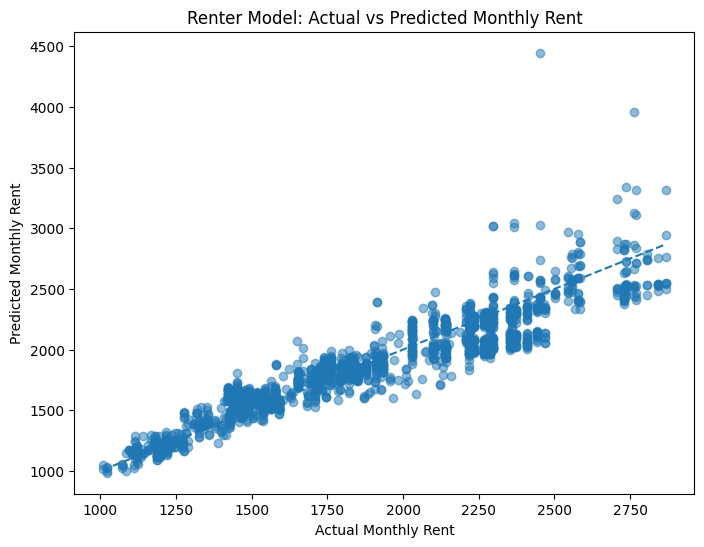

In [182]:
plt.figure(figsize=(8, 6))

plt.scatter(y_rent_test, y_rent_pred, alpha=0.5)

plt.xlabel("Actual Monthly Rent")
plt.ylabel("Predicted Monthly Rent")
plt.title("Renter Model: Actual vs Predicted Monthly Rent")

plt.plot(
    [y_rent_test.min(), y_rent_test.max()],
    [y_rent_test.min(), y_rent_test.max()],
    linestyle="--"
)

plt.show()

The actual vs predicted plot shows that the renter model predicts monthly rent fairly well. Most points follow the dashed line, which means the predicted rents are close to the actual rents.

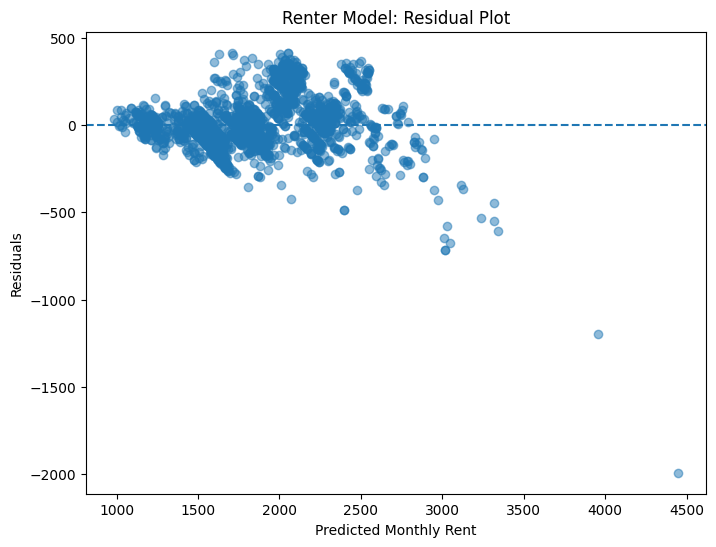

In [183]:
rent_residuals = y_rent_test - y_rent_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_rent_pred, rent_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Monthly Rent")
plt.ylabel("Residuals")
plt.title("Renter Model: Residual Plot")

plt.show()

The residual plot shows that most prediction errors are close to zero. There are a few larger errors, especially for higher predicted rent values, so the model is not perfect. Still, the overall pattern suggests the model is useful for predicting renter housing costs.

In [184]:
rent_coefficients = pd.DataFrame({
    "Variable": X_rent.columns,
    "Coefficient": rent_model.coef_
})

rent_coefficients["Abs_Coefficient"] = rent_coefficients["Coefficient"].abs()

rent_coefficients.sort_values("Abs_Coefficient", ascending=False).head(20)

,Variable,Coefficient,Abs_Coefficient
7,CBSA_Label_New York-Newark-Jersey City,298.316575,298.316575
1,HH_Size,204.123291,204.123291
12,CBSA_Label_Vineland-Bridgeton,-176.007694,176.007694
9,CBSA_Label_Other / Non-CBSA,-108.932399,108.932399
8,CBSA_Label_Ocean City,-105.896737,105.896737
11,CBSA_Label_Trenton-Princeton,97.669079,97.669079
10,CBSA_Label_Philadelphia-Camden-Wilmington,-67.942272,67.942272
13,Generation_G.I Generation,35.775190,35.775190
5,Marital,-13.901495,13.901495
6,CBSA_Label_Atlantic City-Hammonton,-10.689523,10.689523


This  shows the strongest coefficients in the renter model. the model is mainly using household size and metro area to predict estimated monthly rent. This makes sense because rent varies by location, and larger households usually need larger rental units.


In [185]:

# saves the renter model results
rent_mae = mean_absolute_error(y_rent_test, y_rent_pred)

renter_results = pd.DataFrame({
    "Model": ["Renter Model"],
    "Target": ["Monthly_Rent"],
    "R2": [rent_r2],
    "MSE": [rent_mse],
    "RMSE": [rent_rmse],
    "MAE": [rent_mae]
})

renter_results

,Model,Target,R2,MSE,RMSE,MAE
0,Renter Model,Monthly_Rent,0.871674,23073.542623,151.899778,108.05136


## Step 7: Prepare the Owner Model

The second model will use owner households only. The target variable is `Monthly_Mortgage`.

Before building the model, I check which variables seem most related to monthly mortgage cost.

We need to check which numeric variables are most related to monthly mortgage cost. Columns that are too directly connected to mortgage cost are removed so the model does not use information that would make the prediction too obvious.

In [186]:
owner_leakage_cols = [
    "Monthly_Mortgage",
    "Monthly_Housing_Cost",
    "Monthly_Rent",
    "Housing_Cost_Ratio",
    "Is_Cost_Burdened",
    "Estimated_Median_Home_Price",
    "Adjusted_Estimated_Median_Home_Price",
    "Mortgage_Interest_Rate",
    "Annual Change (%)",
    "HPI",
    "HPI with 1990 base",
    "HPI with 2000 base",
    "fmr_0br",
    "fmr_1br",
    "fmr_2br",
    "fmr_3br",
    "fmr_4br",
    "Adjusted_fmr_0br",
    "Adjusted_fmr_1br",
    "Adjusted_fmr_2br",
    "Adjusted_fmr_3br",
    "Adjusted_fmr_4br"
]

owner_numeric_cols = owners.select_dtypes(include="number").columns

owner_candidate_cols = [
    col for col in owner_numeric_cols
    if col not in owner_leakage_cols
]

owner_candidate_corr = (
    owners[owner_candidate_cols + ["Monthly_Mortgage"]]
    .corr(numeric_only=True)["Monthly_Mortgage"]
    .drop("Monthly_Mortgage")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

owner_candidate_corr.head(20)

renter_occupied_hh_15_24     0.773394
owner_occupied_hh_35_44      0.761952
owner_occupied_hh_15_24      0.755749
owner_occupied_hh_25_34      0.735937
owner_occupied_hh_45_54      0.634422
owner_occupied_hh_75_84      0.600501
owner_occupied_total         0.600353
renter_occupied_hh_35_44     0.556720
total_occupied_units         0.534853
renter_occupied_hh_25_34     0.520823
owner_occupied_hh_55_59      0.507740
renter_occupied_hh_45_54     0.492221
Year                        -0.458778
owner_occupied_hh_60_64      0.452658
Inflation_Rate               0.419014
renter_occupied_total        0.402806
owner_occupied_hh_85_plus    0.397394
renter_occupied_hh_55_59     0.395214
owner_occupied_hh_65_74      0.390296
Sub/Urb                     -0.382778
Name: Monthly_Mortgage, dtype: float64

This checks which numeric variables are most related to monthly mortgage cost after removing columns that are too directly connected to the target.

Several ACS summary columns have strong relationships with monthly mortgage cost, but those columns describe the whole metro area and year. To keep the model easier to explain, I will use metro area, year, and household information instead of adding many similar ACS count columns.

In [187]:
categorical_cols = ["CBSA_Label", "Generation", "Education", "Marital"]

for col in categorical_cols:
    print("\n", col)
    display(
        owners.groupby(col)["Monthly_Mortgage"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )


 CBSA_Label


,count,mean
CBSA_Label,,
New York-Newark-Jersey City,17244,2614.061932
Ocean City,166,2114.005783
Trenton-Princeton,824,1828.972621
Other / Non-CBSA,216,1800.251852
Philadelphia-Camden-Wilmington,3900,1544.525554
Atlantic City-Hammonton,922,1501.012711
Allentown-Bethlehem-Easton,202,1489.014059
Vineland-Bridgeton,394,1045.659340



 Generation


,count,mean
Generation,,
G.I Generation,632,2753.252468
Baby Boomers,10392,2335.379831
Silent Generation,4798,2318.556682
Generation X,6374,2315.767207
Millennials,1626,2125.982817
Generation Z,46,2017.060870



 Education


,count,mean
Education,,
33,104,2633.327885
31,6,2519.066667
46,608,2456.769276
45,662,2440.516314
38,190,2432.631368
44,3266,2411.335536
34,242,2396.610579
37,272,2393.261397
35,138,2363.351159



 Marital


,count,mean
Marital,,
1,15354,2348.599188
3,300,2331.010600
7,2478,2315.718588
4,2760,2268.898152
5,2638,2253.407771
6,316,2210.375190
2,22,1859.900909


The category checks show that average monthly mortgage cost changes by metro area and generation. The New York-Newark-Jersey City metro area has the highest average monthly mortgage cost, while Vineland-Bridgeton has the lowest.

Education and marital status also show some differences, but they are coded as numbers, so they are harder to explain directly. They can still be used in the model as category variables.

In [188]:
owner_features = [
    "Year",
    "CBSA_Label",
    "HH_Size",
    "Age",
    "Adjusted_HH_Income",
    "Generation",
    "Education",
    "Marital"
]

owner_target = "Monthly_Mortgage"

owner_model_df = owners[owner_features + [owner_target]].dropna().copy()

owner_model_df.shape

(23868, 9)

This creates the owner modeling dataset. It keeps the variables that will be used to predict monthly mortgage cost.

- `CBSA_Label` matters because housing costs change by metro area.
- `Year` matters because housing costs change over time.
- `HH_Size`, `Age`, `Adjusted_HH_Income`, `Generation`, `Education`, and `Marital` add household context.

HPI, home price, and mortgage rate columns are not used here because they are too directly connected to mortgage cost.

In [189]:
X_owner = pd.get_dummies(owner_model_df[owner_features], drop_first=True)
y_owner = owner_model_df[owner_target]

X_owner.head()

,Year,HH_Size,Age,Adjusted_HH_Income,Education,Marital,CBSA_Label_Atlantic City-Hammonton,CBSA_Label_New York-Newark-Jersey City,CBSA_Label_Ocean City,CBSA_Label_Other / Non-CBSA,CBSA_Label_Philadelphia-Camden-Wilmington,CBSA_Label_Trenton-Princeton,CBSA_Label_Vineland-Bridgeton,Generation_G.I Generation,Generation_Generation X,Generation_Generation Z,Generation_Millennials,Generation_Silent Generation
0,2005,2,60,232932.46,43,1,False,False,False,False,False,False,False,False,False,False,False,True
1,2005,2,76,88757.72,43,1,False,False,False,False,False,False,False,False,False,False,False,True
2,2005,2,70,326170.97,40,1,False,False,False,False,False,False,False,False,False,False,False,True
3,2005,4,38,205701.36,41,1,False,False,False,False,False,False,False,False,True,False,False,False
4,2005,2,65,89717.22,34,1,False,False,False,False,False,False,False,False,False,False,False,True


This separates the owner data into predictor variables and the target variable. It also changes category columns, like metro area and generation, into numeric columns so the regression model can use them.

Next, the owner data needs to be split into training and testing data.

In [190]:
X_owner_train, X_owner_test, y_owner_train, y_owner_test = train_test_split(
    X_owner,
    y_owner,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_owner_train.shape[0])
print("Testing rows:", X_owner_test.shape[0])

Training rows: 19094
Testing rows: 4774


## Step 8: Train the Owner Model

This step trains a multiple linear regression model to predict monthly mortgage cost for owner households.

In [191]:
owner_model = LinearRegression()
owner_model.fit(X_owner_train, y_owner_train)

LinearRegression()

In [192]:
y_owner_pred = owner_model.predict(X_owner_test)

y_owner_pred[:10]

array([2694.38470261, 2500.05674318, 2428.38505456,  864.28061875,
       2079.05529221, 1980.12269375, 2480.71798232, 3122.58181815,
       1998.76118328, 2299.78277676])

In [193]:
owner_mse = mean_squared_error(y_owner_test, y_owner_pred)
owner_rmse = np.sqrt(owner_mse)
owner_r2 = r2_score(y_owner_test, y_owner_pred)

print("Owner Model Results")
print("MSE:", owner_mse)
print("RMSE:", owner_rmse)
print("R²:", owner_r2)

Owner Model Results
MSE: 259460.02482953185
RMSE: 509.37218694146605
R²: 0.5753584425511877


The owner model has an R² of about 0.58, which means it explains about 58% of the variation in monthly mortgage cost in the testing data. The RMSE is about $509, so the model's predictions are usually off by around $509 per month.

This is weaker than the earlier version with HPI, but it is a more conservative model because it avoids using variables that are too directly tied to mortgage cost.

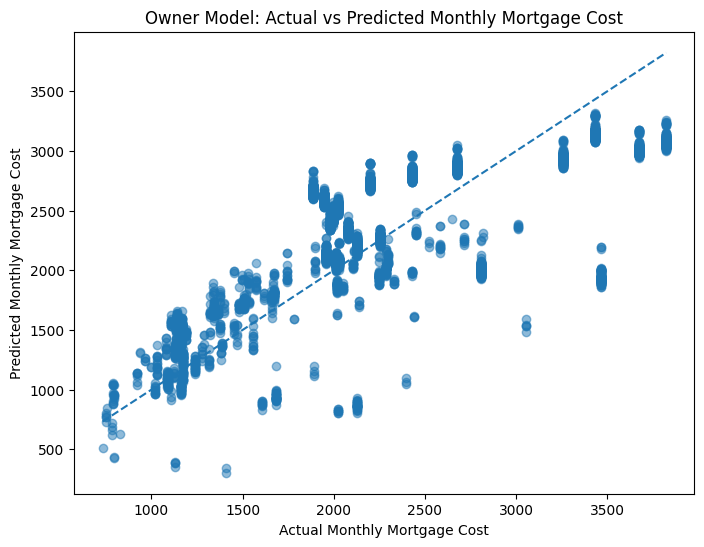

In [194]:
plt.figure(figsize=(8, 6))

plt.scatter(y_owner_test, y_owner_pred, alpha=0.5)

plt.xlabel("Actual Monthly Mortgage Cost")
plt.ylabel("Predicted Monthly Mortgage Cost")
plt.title("Owner Model: Actual vs Predicted Monthly Mortgage Cost")

plt.plot(
    [y_owner_test.min(), y_owner_test.max()],
    [y_owner_test.min(), y_owner_test.max()],
    linestyle="--"
)

plt.show()

The actual vs predicted plot shows that the owner model predicts monthly mortgage cost fairly well. Most points follow the dashed line, which means the predicted mortgage costs are close to the actual values.

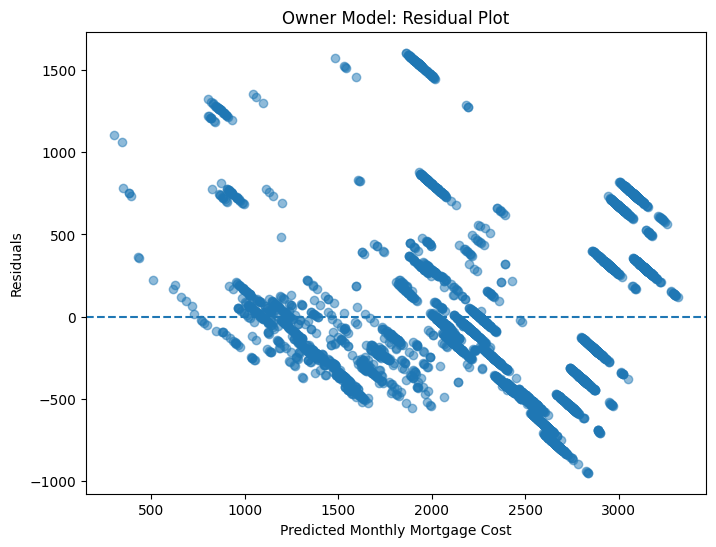

In [195]:
owner_residuals = y_owner_test - y_owner_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_owner_pred, owner_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Monthly Mortgage Cost")
plt.ylabel("Residuals")
plt.title("Owner Model: Residual Plot")

plt.show()

The residual plot shows that the owner model makes some useful predictions, but the errors are not perfectly random. There is still a pattern in the residuals, so the model is useful but not perfect.

In [196]:
owner_coefficients = pd.DataFrame({
    "Variable": X_owner.columns,
    "Coefficient": owner_model.coef_
})

owner_coefficients["Abs_Coefficient"] = owner_coefficients["Coefficient"].abs()

owner_coefficients.sort_values("Abs_Coefficient", ascending=False).head(20)

,Variable,Coefficient,Abs_Coefficient
7,CBSA_Label_New York-Newark-Jersey City,1353.551722,1353.551722
9,CBSA_Label_Other / Non-CBSA,959.557673,959.557673
8,CBSA_Label_Ocean City,642.441300,642.441300
11,CBSA_Label_Trenton-Princeton,527.483397,527.483397
10,CBSA_Label_Philadelphia-Camden-Wilmington,288.307735,288.307735
12,CBSA_Label_Vineland-Bridgeton,-270.324247,270.324247
6,CBSA_Label_Atlantic City-Hammonton,248.157776,248.157776
15,Generation_Generation Z,220.800156,220.800156
13,Generation_G.I Generation,213.551361,213.551361
0,Year,-66.653893,66.653893


This shows the strongest coefficients in the owner model. The largest coefficients are mostly metro area variables, which means location is one of the biggest predictors of estimated monthly mortgage cost.

Generation appears in the model, but its effect is smaller than the location effects. The CBSA and generation coefficients are compared to a baseline group because the category variables were converted into dummy variables.

In [197]:
owner_mae = mean_absolute_error(y_owner_test, y_owner_pred)

owner_results = pd.DataFrame({
    "Model": ["Owner Model"],
    "Target": ["Monthly_Mortgage"],
    "R2": [owner_r2],
    "MSE": [owner_mse],
    "RMSE": [owner_rmse],
    "MAE": [owner_mae]
})

owner_results

,Model,Target,R2,MSE,RMSE,MAE
0,Owner Model,Monthly_Mortgage,0.575358,259460.02483,509.372187,405.26476


This saves the owner model results so they can be compared with the renter model later.

## Step 9: Compare the Renter and Owner Models


In [198]:
model_results = pd.concat([renter_results, owner_results], ignore_index=True)

model_results

,Model,Target,R2,MSE,RMSE,MAE
0,Renter Model,Monthly_Rent,0.871674,23073.542623,151.899778,108.05136
1,Owner Model,Monthly_Mortgage,0.575358,259460.024830,509.372187,405.26476


The renter model performed better than the owner model. The renter model explained about 87% of the variation in estimated monthly rent, while the owner model explained about 58% of the variation in estimated monthly mortgage cost.